In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### Задача 1. EDA

In [3]:
users_info.shape

(1000, 4)

In [4]:
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [5]:
users_info.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [6]:
users_info_cl = users_info[~users_info['age'].isnull()]
users_info_cl = users_info_cl[~users_info_cl['gender'].isnull()]

In [7]:
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


In [8]:
users_info_cl.isnull().sum()

id_user    0
city       0
age        0
gender     0
dtype: int64

In [9]:
users_info_cl.shape

(865, 4)

In [10]:
print(1 - (len(users_info_cl) / len(users_info)))

0.135


In [11]:
users_info_cl['age'].describe()

count    865.000000
mean      39.419653
std       13.774501
min       18.000000
25%       28.000000
50%       37.000000
75%       51.000000
max       65.000000
Name: age, dtype: float64

<Axes: ylabel='age'>

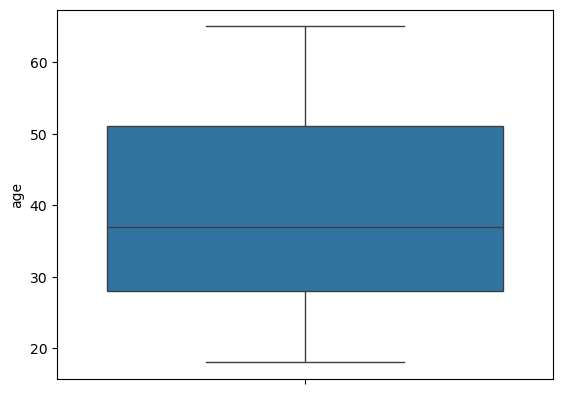

In [12]:
sns.boxplot(users_info_cl['age'])

In [13]:
Q1 = np.percentile(users_info_cl['age'], 25)
Q3 = np.percentile(users_info_cl['age'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(lower_bound)
print(upper_bound)

-6.5
85.5


In [14]:
users_info_cl = users_info_cl.loc[users_info_cl['age'] < upper_bound].copy()
users_info_cl.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female


<Axes: xlabel='age', ylabel='Count'>

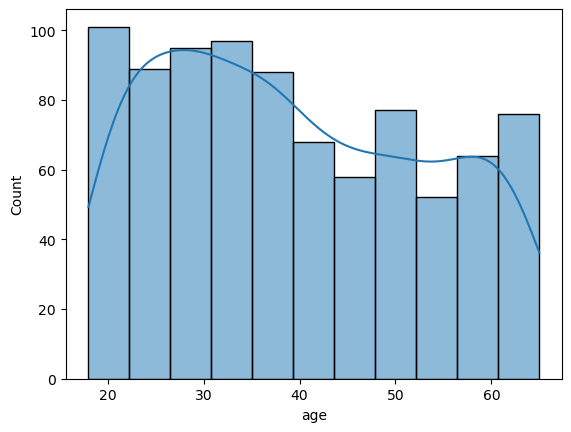

In [15]:
sns.histplot(users_info_cl['age'], kde = True,)

### Задача 2. Доля пользователей-женщин по городам

In [16]:
users_info_cl.groupby(['gender', 'city'])['id_user'].count().reset_index()

,gender,city,id_user
0,female,Екатеринбург,55
1,female,Казань,53
2,female,Москва,220
3,female,СПб,123
4,male,Екатеринбург,78
5,male,Казань,77
6,male,Москва,105
7,male,СПб,154


In [17]:
pivot_users = pd.pivot_table(users_info_cl,\
                            values='id_user', \
                            index=['city'],\
                            columns='gender',\
                            aggfunc=['count'],\
                            fill_value=0).reset_index()
pivot_users.head()

city  count     
gender               female male
0       Екатеринбург     55   78
1             Казань     53   77
2             Москва    220  105
3                СПб    123  154

In [18]:
pivot_users.columns = ['city', 'cnt_female', 'cnt_male']
pivot_users['share_fem'] = pivot_users['cnt_female'] / (pivot_users['cnt_female'] + pivot_users['cnt_male'])
pivot_users.head()

,city,cnt_female,cnt_male,share_fem
0,Екатеринбург,55,78,0.413534
1,Казань,53,77,0.407692
2,Москва,220,105,0.676923
3,СПб,123,154,0.444043


In [19]:
pivot_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   city        4 non-null      object 
 1   cnt_female  4 non-null      int64  
 2   cnt_male    4 non-null      int64  
 3   share_fem   4 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 260.0+ bytes


<Axes: title={'center': 'Доля женщин по городам'}, xlabel='city'>

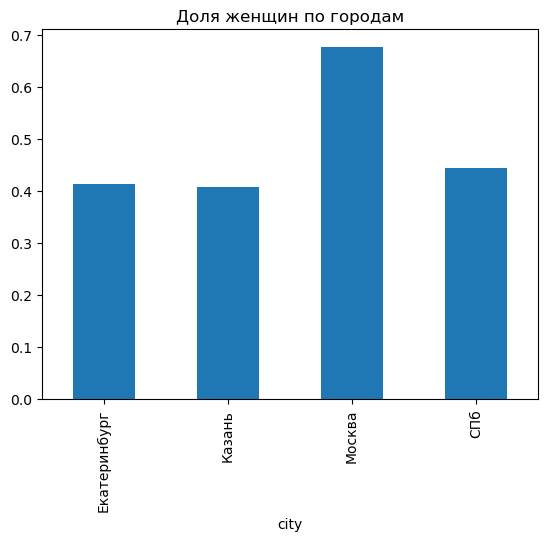

In [20]:
pivot_users.plot(kind = 'bar', y = 'share_fem', x = 'city', legend = False, title = 'Доля женщин по городам')

### Задача 3. Делим пользователей на бины

In [21]:
pay_mon = pd.read_csv('payments_monthly.csv')
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [22]:
pay_mon_2 = pay_mon.groupby('id_user').agg(avg_cnt_tr = ('cnt_total', 'mean')).reset_index()
pay_mon_2.head()

,id_user,avg_cnt_tr
0,1000,3.666667
1,1001,11.727273
2,1002,11.636364
3,1003,5.166667
4,1004,2.000000


In [23]:
bins = [1, 5, 12, float('inf')]
labels = ['низкий', 'средний', 'высокий']
pay_mon_2['group'] = pd.cut(pay_mon_2['avg_cnt_tr'], bins = bins, labels = labels, right = True)
pay_mon_2.head()

,id_user,avg_cnt_tr,group
0,1000,3.666667,низкий
1,1001,11.727273,средний
2,1002,11.636364,средний
3,1003,5.166667,средний
4,1004,2.000000,низкий


In [24]:
pay_mon_2.groupby('group').count()[['id_user']]

C:\Users\AHabitus\AppData\Local\Temp\ipykernel_4076\2786616839.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pay_mon_2.groupby('group').count()[['id_user']]


,id_user
group,
низкий,387
средний,501
высокий,61


In [25]:
pay_mon_2['group'].value_counts()

group
средний    501
низкий     387
высокий     61
Name: count, dtype: int64